# TP Mécanique Physique : Mouvement Brownien - Simulation

---

## Introduction

Le **mouvement brownien** est le mouvement aléatoire de particules microscopiques en suspension dans un fluide. Ce phénomène, observé pour la première fois par le botaniste Robert Brown en 1827, a été expliqué théoriquement par Albert Einstein en 1905.

Avant de se plonger dans des expériences de laboratoire, c'est utile de vérifier si on arrive à reproduire des résultats *in silico*, c'est-à-dire sur l'ordinateur. Cette approche nous permet de :

1. Comprendre les principes fondamentaux du mouvement brownien
2. Développer les outils d'analyse que nous utiliserons sur les données expérimentales
3. Valider notre compréhension en comparant simulation et théorie

### Objectifs de ce TP

- Simuler des marches aléatoires en 2D
- Comprendre le lien entre diffusion et marche aléatoire via la loi de Stokes-Einstein
- Calculer et analyser l'écart quadratique moyen (MSD)
- Extraire le coefficient de diffusion à partir des simulations

In [1]:
# Importation des bibliothèques nécessaires
import math
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# Configuration pour de belles figures
plt.rcParams['figure.figsize'] = [8, 6]
plt.rcParams['font.size'] = 12

---

## 1. Plusieurs marcheurs aléatoires en 2D

Le mouvement brownien peut être modélisé comme une **marche aléatoire** où chaque déplacement est tiré d'une distribution gaussienne (normale).

On peut générer des nombres aléatoires selon certaines distributions avec NumPy. Par exemple, pour générer un nombre selon la distribution gaussienne, on utilise la fonction `np.random.normal`.

La méthode `np.random.normal` possède l'option `size`, qui peut être utilisée pour créer des matrices de nombres aléatoires.

L'étude de plusieurs trajectoires nous permettra d'effectuer des moyennes statistiques et de mieux caractériser le comportement du système.

**Exercice 1.1** Utilisez l'option `size` pour générer une marche aléatoire en deux dimensions pour 10 marcheurs de 100 pas. Calculez la matrice des déplacements et les positions (en $x$ et $y$).

In [2]:
# Génération de plusieurs marcheurs
# shape = (nombre de marcheurs, nombre de pas, 2 dimensions)
n_marcheurs = 10
n_pas = 100
dx_multi = np.random.normal(loc=0.0, scale=1.0, size=[n_marcheurs, n_pas, 2])

# Calcul des positions (somme cumulative selon l'axe 1 = le temps)
x_multi = np.cumsum(dx_multi, axis=1)

print(f"Forme du tableau : {x_multi.shape}")
print(f"  - {n_marcheurs} marcheurs")
print(f"  - {n_pas} pas de temps")
print(f"  - 2 dimensions (x, y)")

Forme du tableau : (10, 100, 2)
  - 10 marcheurs
  - 100 pas de temps
  - 2 dimensions (x, y)


**Exercice 1.2** Utilisez une fonction Matplotlib pour visualiser les trajets des marcheurs en 2D en différentes couleurs.

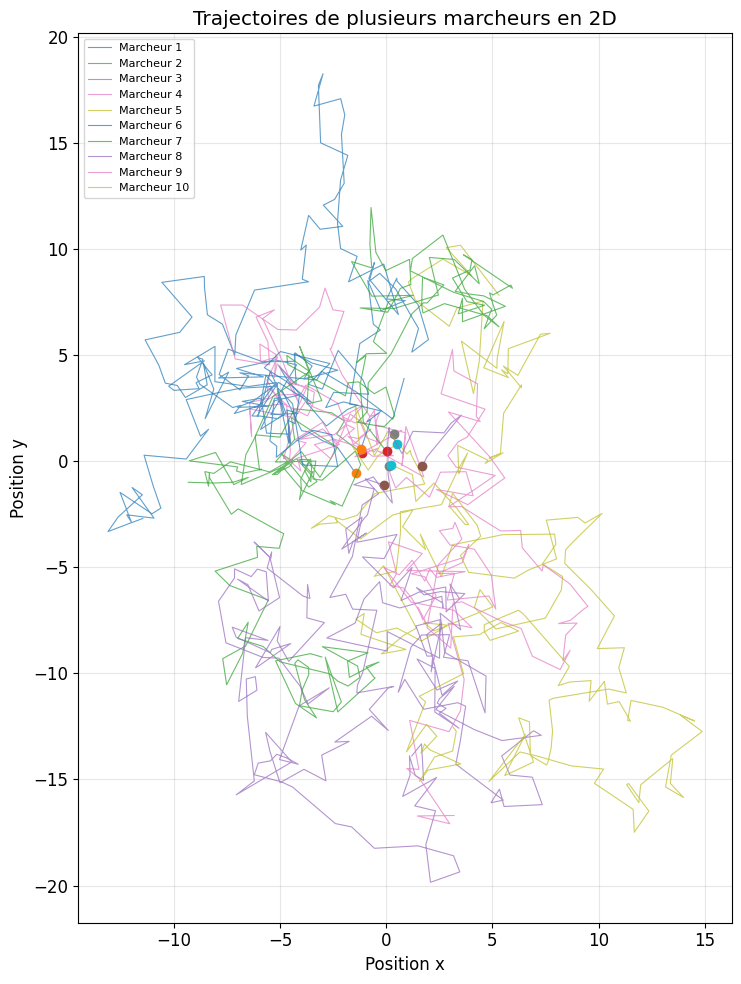

In [3]:
# Trajectoires de plusieurs marcheurs
fig, ax = plt.subplots(figsize=(10, 10))

for i in range(n_marcheurs):
    ax.plot(x_multi[i, :, 0], x_multi[i, :, 1], 
            linewidth=0.8, alpha=0.7, label=f'Marcheur {i+1}')
    ax.plot(x_multi[i, 0, 0], x_multi[i, 0, 1], 'o', markersize=6)

ax.set_title("Trajectoires de plusieurs marcheurs en 2D")
ax.set_xlabel("Position x")
ax.set_ylabel("Position y")
ax.set_aspect('equal', 'box')
ax.legend(loc='upper left', fontsize=8)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

---

## 2. Loi de Stokes-Einstein

En 1905, Einstein fait le lien entre la **diffusion** (mouvement des particules d'une zone à haute concentration vers une zone à basse concentration jusqu'à l'équilibre) et les **marches aléatoires**.

Pour des particules sphériques de soluté dans un solvant, on peut utiliser la **loi de Stokes-Einstein** pour calculer le coefficient de diffusion :

$$D = \frac{k_B T}{6\pi\eta R}$$

où :
- $D$ : coefficient de diffusion (m²/s)
- $k_B = 1.38 \times 10^{-23}$ J/K : constante de Boltzmann
- $T$ : température absolue (K)
- $\eta$ : viscosité dynamique du fluide (Pa·s)
- $R$ : rayon de la particule (m)

Le lien avec la marche aléatoire est donné par l'**écart quadratique moyen** (MSD) :

$$\langle r^2 \rangle = 4Dt \quad \text{(en 2D)}$$

Ainsi, l'écart-type des déplacements sur un intervalle de temps $\Delta t$ est :
$$\sigma = \sqrt{2D\Delta t}$$

**Exercice 2.1** Calculez les coefficients de diffusion pour des particules de rayons $R = \{0.5, 1.0, 2.0\} \, \mu\text{m}$ dans l'eau (viscosité $\eta = 1 \times 10^{-3}$ Pa·s) à température ambiante ($T = 25°\text{C} = 298.15$ K).

In [4]:
# Constantes physiques
kB = 1.38e-23    # Constante de Boltzmann (J/K)
T = 298.15       # Température (K) - correspond à 25°C
eta = 1.0e-3     # Viscosité de l'eau (Pa·s)

# Rayons des particules (en micromètres)
rayons = [0.5, 1.0, 2.0]

print("Coefficient de diffusion pour différents rayons de particules :")
print("=" * 60)

for R in rayons:
    # Conversion du rayon en mètres
    R_m = R * 1e-6
    # Calcul du coefficient de diffusion
    D = kB * T / (6 * math.pi * eta * R_m)
    print(f"R = {R:5.2f} µm  -->  D = {D:.4e} m²/s")

Coefficient de diffusion pour différents rayons de particules :
R =  0.50 µm  -->  D = 4.3656e-13 m²/s
R =  1.00 µm  -->  D = 2.1828e-13 m²/s
R =  2.00 µm  -->  D = 1.0914e-13 m²/s


**Exercice 2.2** Utilisez les valeurs de $D$ que vous avez calculées pour redimensionner les marches aléatoires. Prenez des intervalles de temps de 100 ms et simulez 5 trajectoires de 600 pas.

In [5]:
# Paramètres de simulation
dt = 0.1       # Intervalle de temps (s)
n_pas = 600    # Nombre de pas
n_traj = 5     # Nombre de trajectoires
R = 1.0        # Rayon de la particule (µm)

# Calcul du coefficient de diffusion
D = kB * T / (6 * math.pi * eta * R * 1e-6)
print(f"Coefficient de diffusion D = {D:.4e} m²/s")

# Écart-type des déplacements
sigma = np.sqrt(2 * D * dt)
print(f"Écart-type des déplacements σ = {sigma:.4e} m")

# Génération des trajectoires
dx = np.random.normal(loc=0.0, scale=sigma, size=(n_traj, n_pas, 2))
x = np.cumsum(dx, axis=1)

Coefficient de diffusion D = 2.1828e-13 m²/s
Écart-type des déplacements σ = 2.0894e-07 m


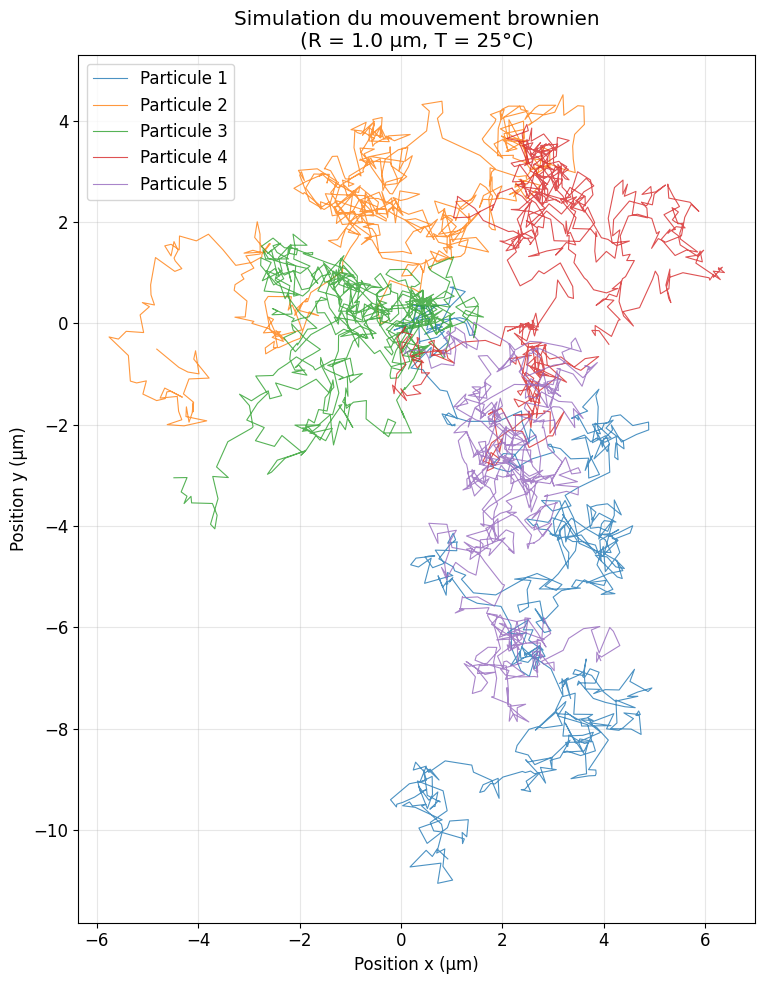

In [6]:
# Visualisation des trajectoires
fig, ax = plt.subplots(figsize=(10, 10))

for i in range(n_traj):
    # Conversion en micromètres pour la visualisation
    ax.plot(x[i, :, 0] * 1e6, x[i, :, 1] * 1e6, 
            linewidth=0.8, alpha=0.8, label=f'Particule {i+1}')

ax.set_title(f"Simulation du mouvement brownien\n(R = {R} µm, T = {T-273.15:.0f}°C)")
ax.set_xlabel("Position x (µm)")
ax.set_ylabel("Position y (µm)")
ax.set_aspect('equal', 'box')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

---

## 3. Écart quadratique moyen (MSD) en fonction du temps

L'écart quadratique moyen (Mean Square Displacement - MSD) est la quantité clé pour caractériser le mouvement brownien. Vous devez maintenant calculer le MSD :

$$\text{MSD}(\tau) = \frac{1}{N} \sum_{i=0}^{N-1} |\vec{r}_i(\tau) - \vec{r}_i(0)|^2$$

Vous pouvez également calculer le MSD autrement, en utilisant une **moyenne sur fenêtres temporelles** :

$$\text{MSD}(\tau) = \frac{1}{N(M-k)} \sum_{i=0}^{N-1} \sum_{j=0}^{M-k-1} |\vec{r}_i(t_j+\tau) - \vec{r}_i(t_j)|^2$$

Cette seconde méthode est plus robuste car elle utilise mieux les données disponibles.

**Exercice 3.1** À partir des trajectoires simulées, calculez l'écart quadratique moyen (MSD) avec les deux méthodes. Effectuez un fit linéaire et comparez les coefficients de diffusion obtenus. Comment évaluer la qualité des fits que vous avez fait ?

In [7]:
# Paramètres de simulation pour le calcul du MSD
dt = 0.1           # Intervalle de temps (s)
n_pas = 600        # Nombre de pas
n_particules = 100 # Nombre de particules
R = 1.0            # Rayon (µm)

# Calcul du coefficient de diffusion théorique
D_theo = kB * T / (6 * math.pi * eta * R * 1e-6)
print(f"Coefficient de diffusion théorique : D = {D_theo:.4e} m²/s")

# Écart-type des déplacements
sigma = np.sqrt(2 * D_theo * dt)

# Génération des trajectoires
dx = np.random.normal(loc=0.0, scale=sigma, size=[n_particules, n_pas, 2])
x = np.cumsum(dx, axis=1)

Coefficient de diffusion théorique : D = 2.1828e-13 m²/s


In [8]:
def compute_msd_ensemble(trajectoires):
    """
    Calcule le MSD par moyenne d'ensemble (méthode 1).
    
    Paramètres:
        trajectoires : array de shape (N, M, 2)
                      N = nombre de particules
                      M = nombre de pas de temps
    
    Retourne:
        msd : array de shape (M,) contenant le MSD à chaque instant
    """
    N, M, _ = trajectoires.shape
    # Calcul du carré de la distance à l'origine pour chaque particule
    r2 = np.sum(trajectoires**2, axis=2)  # shape: (N, M)
    # Moyenne sur les particules
    msd = np.mean(r2, axis=0)  # shape: (M,)
    return msd


def compute_msd_fenetre(trajectoires):
    """
    Calcule le MSD par moyenne sur fenêtres temporelles (méthode 2).
    
    Cette méthode est plus robuste car elle utilise toutes les paires
    de temps séparées par un même intervalle τ.
    
    Paramètres:
        trajectoires : array de shape (N, M, 2)
    
    Retourne:
        msd : array de shape (M,) contenant le MSD pour chaque décalage τ
    """
    N, M, _ = trajectoires.shape
    msd = np.zeros(M)
    
    for k in range(1, M):
        # Déplacement entre t+k et t
        delta = trajectoires[:, k:, :] - trajectoires[:, :-k, :]
        # Carré de la distance
        dr2 = np.sum(delta**2, axis=2)
        # Moyenne sur particules et fenêtres
        msd[k] = np.mean(dr2)
    
    return msd

In [9]:
# Calcul des MSD avec les deux méthodes
msd_ensemble = compute_msd_ensemble(x)
msd_fenetre = compute_msd_fenetre(x)

In [10]:
# Fonction linéaire pour le fit
def fonction_lineaire(t, a):
    """MSD = a * t, où a = 4D en 2D"""
    return a * t

# Fonction pour calculer le R² (qualité du fit)
def r_squared(y_obs, y_pred):
    """Calcule le coefficient de détermination R²"""
    ss_res = np.sum((y_obs - y_pred)**2)
    ss_tot = np.sum((y_obs - np.mean(y_obs))**2)
    return 1 - ss_res / ss_tot

# Vecteur temps
t = dt * np.arange(len(msd_ensemble))

# Fenêtre pour le fit (première moitié des données)
k_min = 1
k_max = len(t) // 2
t_fit = t[k_min:k_max]

In [11]:
# Fit de la méthode d'ensemble
popt_ens, pcov_ens = curve_fit(fonction_lineaire, t_fit, msd_ensemble[k_min:k_max])
a_ens = popt_ens[0]
D_ens = a_ens / 4  # En 2D : MSD = 4Dt
r2_ens = r_squared(msd_ensemble[k_min:k_max], fonction_lineaire(t_fit, a_ens))

# Fit de la méthode par fenêtres
popt_fen, pcov_fen = curve_fit(fonction_lineaire, t_fit, msd_fenetre[k_min:k_max])
a_fen = popt_fen[0]
D_fen = a_fen / 4
r2_fen = r_squared(msd_fenetre[k_min:k_max], fonction_lineaire(t_fit, a_fen))

print("Résultats des fits :")
print("=" * 60)
print(f"Méthode d'ensemble : D = {D_ens:.4e} m²/s, R² = {r2_ens:.4f}")
print(f"Méthode par fenêtres : D = {D_fen:.4e} m²/s, R² = {r2_fen:.4f}")
print(f"Valeur théorique : D = {D_theo:.4e} m²/s")
print(f"\nErreur relative (ensemble) : {abs(D_ens - D_theo)/D_theo * 100:.2f}%")
print(f"Erreur relative (fenêtres) : {abs(D_fen - D_theo)/D_theo * 100:.2f}%")

Résultats des fits :
Méthode d'ensemble : D = 2.5622e-13 m²/s, R² = 0.9936
Méthode par fenêtres : D = 2.2383e-13 m²/s, R² = 0.9998
Valeur théorique : D = 2.1828e-13 m²/s

Erreur relative (ensemble) : 17.38%
Erreur relative (fenêtres) : 2.54%


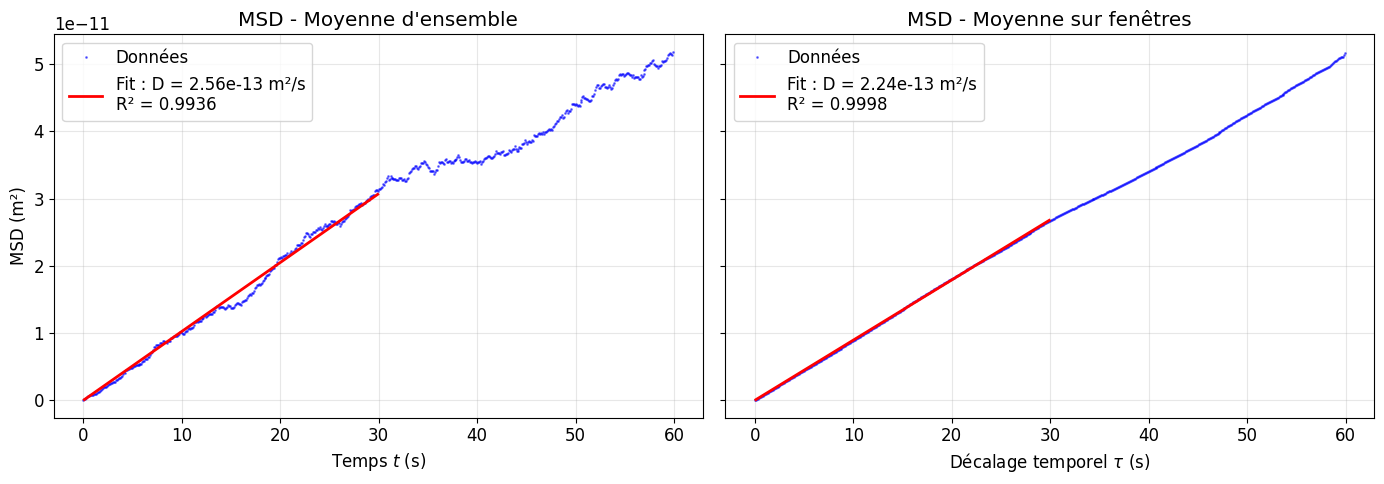

In [12]:
# Visualisation des résultats
fig, axs = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

# MSD d'ensemble
axs[0].plot(t, msd_ensemble, 'b.', markersize=2, alpha=0.5, label="Données")
axs[0].plot(t_fit, fonction_lineaire(t_fit, a_ens), 'r-', linewidth=2,
            label=f"Fit : D = {D_ens:.2e} m²/s\nR² = {r2_ens:.4f}")
axs[0].set_xlabel(r"Temps $t$ (s)")
axs[0].set_ylabel(r"MSD (m²)")
axs[0].set_title("MSD - Moyenne d'ensemble")
axs[0].legend()
axs[0].grid(True, alpha=0.3)

# MSD par fenêtres
axs[1].plot(t, msd_fenetre, 'b.', markersize=2, alpha=0.5, label="Données")
axs[1].plot(t_fit, fonction_lineaire(t_fit, a_fen), 'r-', linewidth=2,
            label=f"Fit : D = {D_fen:.2e} m²/s\nR² = {r2_fen:.4f}")
axs[1].set_xlabel(r"Décalage temporel $\tau$ (s)")
axs[1].set_title("MSD - Moyenne sur fenêtres")
axs[1].legend()
axs[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

---

## Conclusion

Dans ce TP de simulation, nous avons :

1. **Généré des marches aléatoires en 2D** pour modéliser le mouvement brownien de plusieurs particules
2. **Appliqué la loi de Stokes-Einstein** pour calculer le coefficient de diffusion théorique pour différentes tailles de particules ($R = 0.5, 1.0, 2.0$ µm)
3. **Calculé le MSD** avec deux méthodes différentes (moyenne d'ensemble et moyenne sur fenêtres)
4. **Extrait le coefficient de diffusion** à partir des simulations par fit linéaire
5. **Évalué la qualité des fits** en calculant le coefficient de détermination $R^2$

### Points clés à retenir

- Le mouvement brownien est bien décrit par une marche aléatoire gaussienne
- Le MSD croît linéairement avec le temps : $\langle r^2 \rangle = 4Dt$ (en 2D)
- La méthode de moyenne sur fenêtres donne généralement des résultats plus robustes
- Le coefficient $R^2$ permet d'évaluer la qualité du fit (proche de 1 = bon fit)
- Le coefficient de diffusion diminue quand le rayon augmente ($D \propto 1/R$)